In [1]:
# Upload your kaggle.json first (from kaggle.com > account > API)
from google.colab import files
files.upload()  # upload kaggle.json when prompted

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('pip install kaggle -q')
print('Kaggle API ready')

Saving kaggle.json to kaggle.json
Kaggle API ready


In [2]:
os.system('kaggle competitions download -c amex-default-prediction -f train_labels.csv -p /content/')
os.system('unzip -o /content/train_labels.csv.zip -d /content/ 2>/dev/null || true')

import pandas as pd
import numpy as np

labels = pd.read_csv('/content/train_labels.csv')
print(f'Total customers: {labels.shape[0]:,}')

# Sample 10% stratified
sample_ids = set(
    labels
    .groupby('target', group_keys=False)
    .apply(lambda x: x.sample(frac=0.10, random_state=42))
    ['customer_ID']
    .values
)
df_labels = labels[labels['customer_ID'].isin(sample_ids)].reset_index(drop=True)
print(f'Sampled: {len(sample_ids):,} customers')
print(df_labels['target'].value_counts())

Total customers: 458,913
Sampled: 45,891 customers
target
0    34008
1    11883
Name: count, dtype: int64


/tmp/ipykernel_30883/362376593.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.10, random_state=42))


In [3]:
# This downloads the full file but we process it immediately
os.system('kaggle competitions download -c amex-default-prediction -f train_data.csv -p /content/')
os.system('unzip -o /content/train_data.csv.zip -d /content/ 2>/dev/null || true')

TRAIN_PATH = '/content/train_data.csv'

# Peek for dtypes
peek = pd.read_csv(TRAIN_PATH, nrows=1000)
obj_cols = peek.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in obj_cols if c not in ['customer_ID', 'S_2']]
dtype_map = {
    col: 'float32'
    for col in peek.columns
    if col not in obj_cols
    and col not in ['customer_ID', 'S_2']
}
print(f'Cols: {len(peek.columns)} | float32: {len(dtype_map)} | cat: {cat_cols}')

# Aggregate on the fly
CHUNKSIZE = 5_000  # smaller = safer on Colab
agg_parts = []

for i, chunk in enumerate(pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE, dtype=dtype_map)):
    filtered = chunk[chunk['customer_ID'].isin(sample_ids)]
    if len(filtered) == 0:
        continue
    agg_chunk = (
        filtered
        .sort_values('S_2')
        .groupby('customer_ID')
        .last()
        .reset_index()
    )
    agg_parts.append(agg_chunk)
    if i % 200 == 0:
        import psutil
        ram = psutil.virtual_memory().percent
        print(f'  Chunk {i} | parts: {len(agg_parts)} | RAM: {ram:.1f}%')

df_combined = pd.concat(agg_parts, ignore_index=True)
df = (
    df_combined
    .sort_values('S_2')
    .groupby('customer_ID')
    .last()
    .reset_index()
    .merge(df_labels, on='customer_ID')
)

print(f'\nShape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# Save to Drive so you never have to rerun this
from google.colab import drive
drive.mount('/content/drive')
df.to_csv('/content/drive/MyDrive/pie_sample_cleaned.csv', index=False)
print('Saved to Google Drive — safe even if Colab disconnects')

Cols: 190 | float32: 186 | cat: ['D_63', 'D_64']
  Chunk 0 | parts: 1 | RAM: 9.7%
  Chunk 200 | parts: 201 | RAM: 9.8%
  Chunk 400 | parts: 401 | RAM: 9.8%
  Chunk 600 | parts: 601 | RAM: 9.8%
  Chunk 800 | parts: 801 | RAM: 9.9%
  Chunk 1000 | parts: 1001 | RAM: 10.1%

Shape: (45891, 191)
Memory: 47.0 MB
Mounted at /content/drive
Saved to Google Drive — safe even if Colab disconnects


In [4]:
df.head()

,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,2018-03-12,0.880875,0.009704,0.004284,0.812649,0.006450,NaN,0.003796,0.007196,...,NaN,NaN,0.007383,0.006623,0.000964,NaN,0.002202,0.000834,0.003444,0
1,0000d17a1447b25a01e42e1ac56b091bb7cbb06317be4c...,2018-03-23,1.009762,0.006181,-0.000886,1.006692,0.006112,0.116401,0.000824,0.149496,...,NaN,NaN,0.002262,0.005217,0.002153,NaN,0.001170,0.003350,0.000675,0
2,0004837f0c785928a29a6f83f70f4a1c54caec483a773f...,2018-03-02,0.642295,0.685210,0.429796,0.024450,0.005188,0.221216,0.009708,0.357104,...,NaN,NaN,0.002107,0.001215,0.003079,NaN,0.003943,0.005832,0.000346,0
3,0005a6ae24fd274640a237ea56c43b1ef9e32077ad168a...,2018-03-16,0.988091,0.238952,0.056075,1.006357,0.007237,0.082842,0.000598,0.005760,...,NaN,NaN,0.003747,0.002857,0.008170,NaN,0.006951,0.000186,0.009110,0
4,00062483fb33d6129dd4ee7e5a12f751d2e7010ac0df01...,2018-03-11,0.573481,0.000626,0.021270,0.818519,0.009274,0.177161,0.001771,0.003341,...,NaN,NaN,0.005230,0.008198,0.004536,NaN,0.004462,0.008460,0.000035,0


In [5]:
FEATURE_GROUPS = {
    'Delinquency': [c for c in df.columns if c.startswith('D_')],
    'Spend':       [c for c in df.columns if c.startswith('S_')],
    'Payment':     [c for c in df.columns if c.startswith('P_')],
    'Balance':     [c for c in df.columns if c.startswith('B_')],
    'Risk':        [c for c in df.columns if c.startswith('R_')],
}

print('PIE Feature Category Mapping')
print('=' * 40)
total = 0
for grp, cols in FEATURE_GROUPS.items():
    print(f'  {grp:<15} {len(cols):>3} features')
    total += len(cols)
print(f'  {"TOTAL":<15} {total:>3} features')

cat_cols = ['D_63', 'D_64']  # confirmed from earlier
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'\nNumerical: {len(num_cols)} | Categorical: {cat_cols}')

PIE Feature Category Mapping
  Delinquency      96 features
  Spend            22 features
  Payment           3 features
  Balance          40 features
  Risk             28 features
  TOTAL           189 features

Numerical: 187 | Categorical: ['D_63', 'D_64']


Features with missing values: 108 / 191
Features with >50% missing:   26
Features with >80% missing:   22


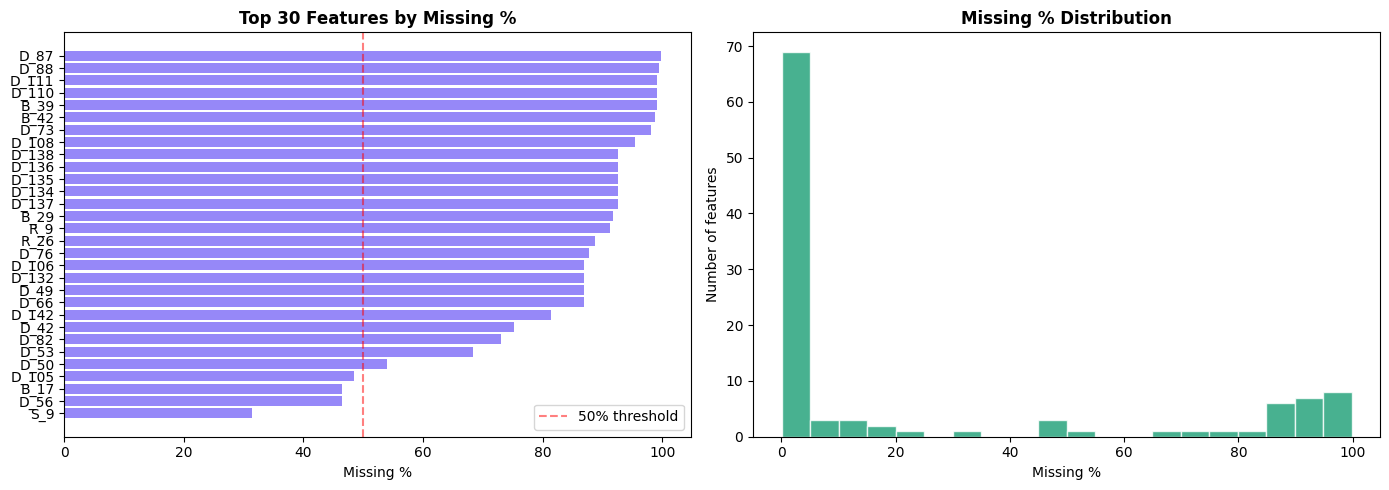

Saved: missing_analysis.png


In [6]:
import matplotlib.pyplot as plt

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f'Features with missing values: {len(missing)} / {df.shape[1]}')
print(f'Features with >50% missing:   {(missing > 50).sum()}')
print(f'Features with >80% missing:   {(missing > 80).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top30 = missing.head(30)
axes[0].barh(top30.index[::-1], top30.values[::-1], color='#7c6af7', alpha=0.8)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Top 30 Features by Missing %', fontweight='bold')
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[0].legend()

axes[1].hist(missing.values, bins=20, color='#1a9e75', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Missing %')
axes[1].set_ylabel('Number of features')
axes[1].set_title('Missing % Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/missing_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: missing_analysis.png')

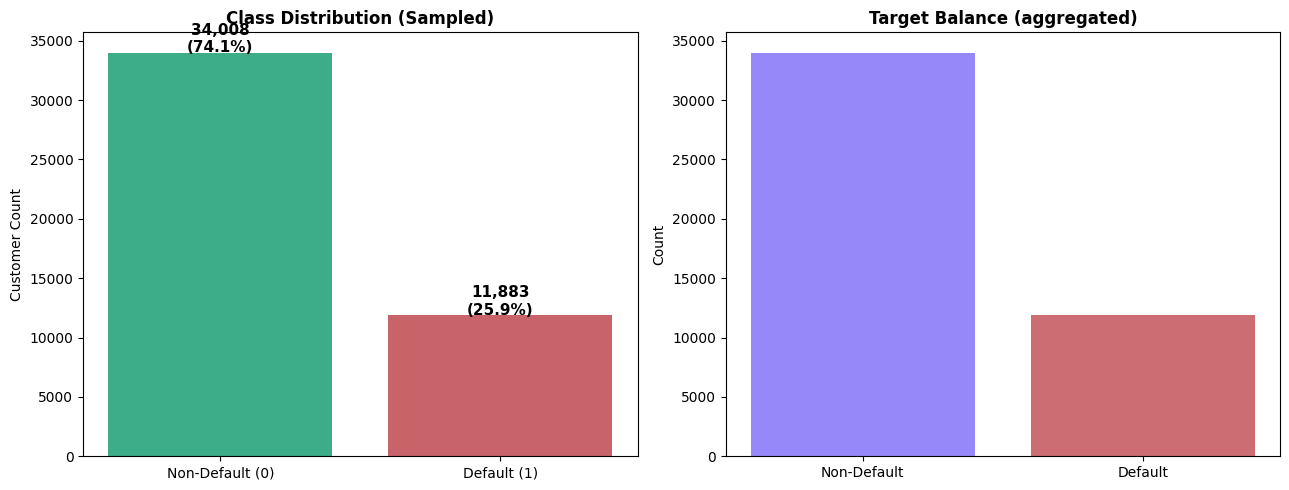

Imbalance ratio: 1:2.9


In [7]:
stmt_counts = df.groupby('customer_ID')['S_2'].count() if 'S_2' in df.columns else None

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['target'].value_counts()
colors = ['#1a9e75', '#c04850']
axes[0].bar(['Non-Default (0)', 'Default (1)'], counts.values, color=colors, alpha=0.85)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/counts.sum()*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Sampled)', fontweight='bold')
axes[0].set_ylabel('Customer Count')

# Statements col gone after agg — show target distribution instead
axes[1].bar(['Non-Default', 'Default'], counts.values, color=['#7c6af7', '#c04850'], alpha=0.8)
axes[1].set_title('Target Balance (aggregated)', fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/class_balance.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: 1:{counts.iloc[0]/counts.iloc[1]:.1f}')

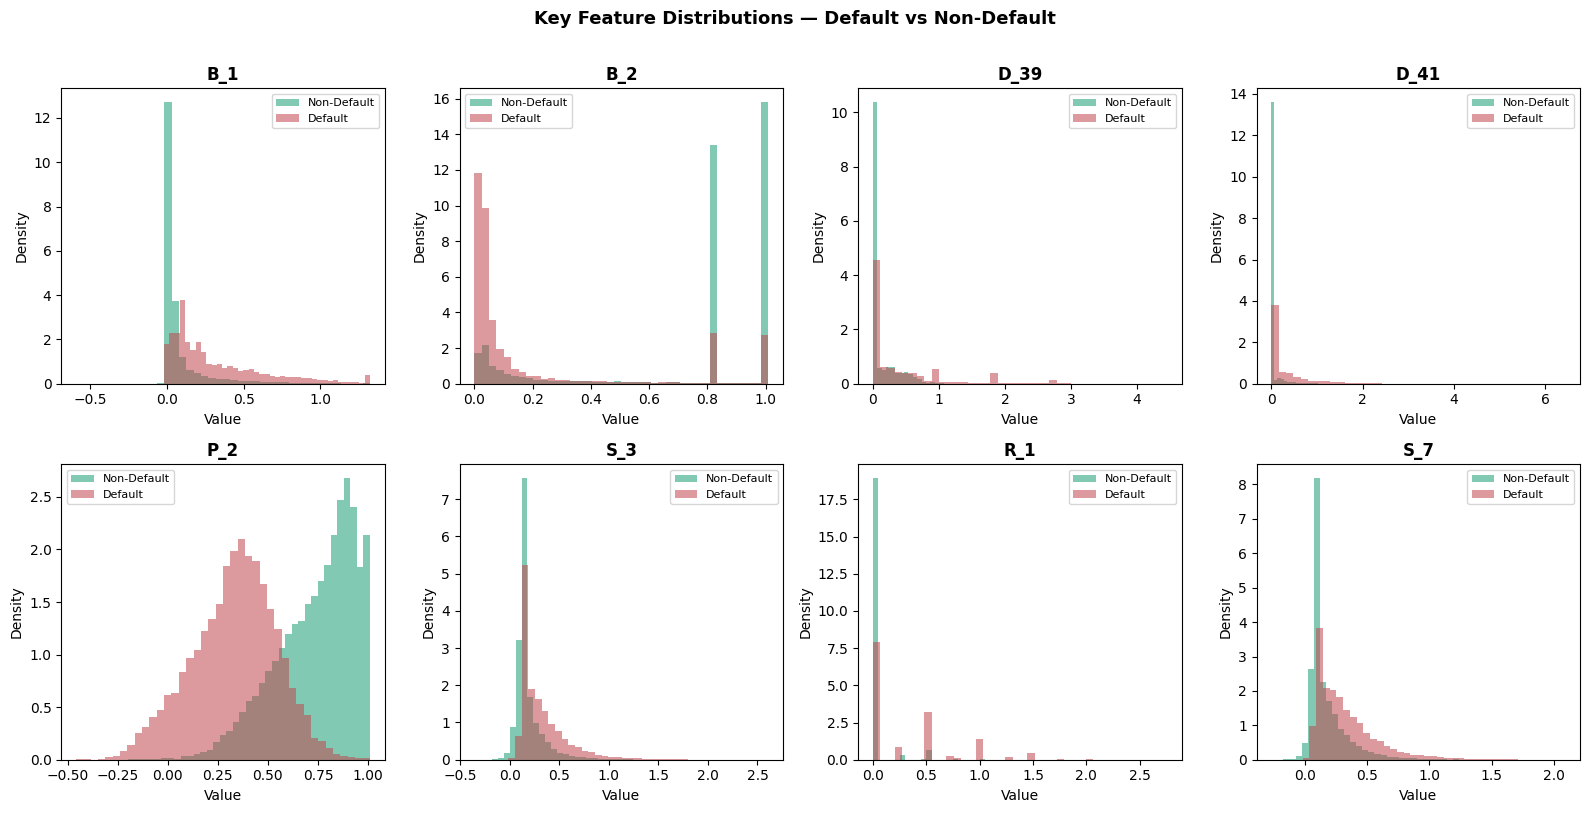

Saved: feature_distributions.png


In [8]:
KEY_FEATURES = ['B_1', 'B_2', 'D_39', 'D_41', 'P_2', 'S_3', 'R_1', 'S_7']
KEY_FEATURES = [f for f in KEY_FEATURES if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES):
    for label_val, color, name in [(0, '#1a9e75', 'Non-Default'), (1, '#c04850', 'Default')]:
        subset = df[df['target'] == label_val][feat].dropna()
        axes[i].hist(subset, bins=40, alpha=0.55, color=color,
                     label=name, density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Key Feature Distributions — Default vs Non-Default',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

In [9]:
# Encode categoricals
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category').cat.codes

# Fill missing with median
num_features = [c for c in df.columns
                if c not in ['customer_ID', 'S_2', 'target']]
df[num_features] = df[num_features].fillna(df[num_features].median())

print(f'Final shape: {df.shape}')
print(f'Missing remaining: {df.isnull().sum().sum()}')

OUTPUT = '/content/drive/MyDrive/pie_sample_cleaned.csv'
df.to_csv(OUTPUT, index=False)
print(f'\nSaved to Drive: {OUTPUT}')
print('Part 1 complete. Use this CSV as input for Part 2.')

Final shape: (45891, 191)
Missing remaining: 0

Saved to Drive: /content/drive/MyDrive/pie_sample_cleaned.csv
Part 1 complete. Use this CSV as input for Part 2.
